As you saw in the lectures, in a decision tree, we decide if a node will be split or not by looking at the **information gain** that split would give us. (Image of video IG) 
Where 
    $$\text{Information Gain} = H(p_1^\text{node})- \left(w^{\text{left}}H\left(p_1^\text{left}\right) + w^{\text{right}}H\left(p_1^\text{right}\right)\right),$$

and $H$ is the entropy, defined as 
$$H(p_1) = -p_1 \text{log}_2(p_1) - (1- p_1) \text{log}_2(1- p_1)$$

Remeber that log here is defined to be in base 2. 

Note that the H attains its higher value when p = 0.5. This means that the probability of event is 0.5. And its minimum value is attained in $p = 0$ and $p = 1$
i.e., the probability of the event happening is totally predictable. Thus, the entropy shows the predictability of an event

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
def plot_entropy(): 
    def entropy(p): 
        if p == 0 or p == 1: 
            return 0 
        else: 
            return -p * np.log2(p) - (1-p)*np.log2(1 - p) 
    p_array = np.linspace(0, 1, 201) 
    h_array = [entropy(p) for p in p_array]
    fig, ax = plt.subplots()
    plt.subplots_adjust(left = 0.25, bottom = 0.25) 
    ax.set_title('p x H(p)') 
    ax.set_xlabel('p') 
    ax.set_ylabel('H(p)') 
    axfreq = plt.axes([0.25, 0.1, 0.65, 0.03])
    h_plot = ax.plot(p_array, h_array) 
    scatter = ax.scatter(0, 0, color = 'red', zorder = 100, s = 70) 

    def update(val): 
        x = val 
        y = entropy(x) 
        scatter.set_offsets((x, y))

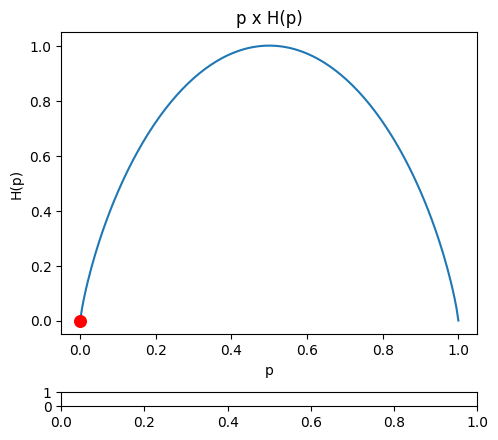

In [4]:
_ = plot_entropy()

We will use **one-hot encoding** to encode the categorical features. They will be as follows: 
* Ear Shape: Pointy = 1, Floppy = 0
* Face Shape: Round = 1, Not Round = 0
* Whiskers: Present = 1, Absent = 0

Therefore, we have two sets:

- `X_train`: for each example, contains 3 features:
            - Ear Shape (1 if pointy, 0 otherwise)
            - Face Shape (1 if round, 0 otherwise)
            - Whiskers (1 if present, 0 otherwise)
            
- `y_train`: whether the animal is a cat
            - 1 if the animal is a cat
            - 0 otherwise

In [5]:
X_train = np.array([[1, 1, 1],
[0, 0, 1],
 [0, 1, 0],
 [1, 0, 1],
 [1, 1, 1],
 [1, 1, 0],
 [0, 0, 0],
 [1, 1, 0],
 [0, 1, 0],
 [0, 1, 0]])

y_train = np.array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0])

In [6]:
X_train[0]

array([1, 1, 1])

In [7]:
def entropy(p): 
    if p == 0 or p == 1: 
        return 0
    else: 
        return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

In [8]:
def split_indices(X, index_feature): 
    """Given a dataset and a index feature, return two lists for the two split nodes, the left node has the animals that have 
    that feature = 1 and the right node those that have the feature = 0 
    index feature = 0 => ear shape
    index feature = 1 => face shape
    index feature = 2 => whiskers
    """
    left_indices = []
    right_indices = []
    for i, x in enumerate(X): 
        if x[index_feature] == 1: 
            left_indices.append(i)
        else: 
            right_indices.append(i) 
    return left_indices, right_indices

In [9]:
split_indices(X_train, 0) 

([0, 3, 4, 5, 7], [1, 2, 6, 8, 9])

In [10]:
def weighted_entropy(X, y, left_indices, right_indices): 
    w_left = len(left_indices) / len(X) 
    w_right = len(right_indices) / len(X) 
    p_left = sum(y[left_indices]) / len(left_indices) 
    p_right = sum(y[right_indices]) / len(right_indices) 

    weighted_entropy = w_left * entropy(p_left) + w_right * entropy(p_right) 
    return weighted_entropy

In [14]:
def information_gain(X, y, left_indices, right_indices): 
    p_node = sum(y) / len(y) 
    h_node = entropy(p_node) 
    w_entropy = weighted_entropy(X, y, left_indices, right_indices) 
    return h_node - w_entropy

In [15]:
left_indices, right_indices = split_indices(X_train, 0) 
information_gain(X_train, y_train, left_indices, right_indices)

0.2780719051126377

In [16]:
for i, feature_name in enumerate(['Ear Shape', 'Face Shape', 'Whisker']): 
    left_indices, right_indices = split_indices(X_train, i) 
    i_gain = information_gain(X_train, y_train, left_indices, right_indices)
    print(f"Feature: {feature_name}, information gain if we split the root node using this feature: {i_gain:.2f}") 

Feature: Ear Shape, information gain if we split the root node using this feature: 0.28
Feature: Face Shape, information gain if we split the root node using this feature: 0.03
Feature: Whisker, information gain if we split the root node using this feature: 0.12


In [34]:
def compute_entropy(y):

    entropy = 0
    
    if len(y) == 0:
        return 0
    entropy = sum(y[y==1])/len(y)
    if entropy == 0 or entropy == 1:
        return 0
    else:
        return -entropy*np.log2(entropy) - (1-entropy)*np.log2(1-entropy)

In [27]:
def split_dataset(X, node_indices, feature):

    left_indices = []
    right_indices = []

    for i in node_indices:
        if X[i][feature] == 1:
            left_indices.append(i)
        else:
            right_indices.append(i)
        
    return left_indices, right_indices 

In [35]:
def compute_information_gain(X, y, node_indices, feature): 
    left_indices, right_indices = split_dataset(X, node_indices, feature) 

    X_node, y_node = X[node_indices], y[node_indices]
    X_left, y_left = X[left_indices], y[left_indices]
    X_right, y_right = X[right_indices], y[right_indices]

    information_gain = 0

    node_entropy = compute_entropy(y_node) 
    left_entropy = compute_entropy(y_left) 
    right_entropy = compute_entropy(y_right) 
    w_left = len(X_left) / len(X_node) 
    w_right = len(X_right) / len(X_node) 
    weighted_entropy = w_left * left_entropy + w_right * right_entropy 
    information_gain = node_entropy - weighted_entropy 

    return information_gain

In [18]:
def get_best_split(X, y, node_indices): 
    num_features = X.shape[1]

    best_feature = -1 
    max_info_gain = 0
    for feature in range(num_features): 
        info_gain = compute_information_gain(X, y, node_indices, feature)
        if info_gain > max_info_gain: 
            max_info_gain = info_gain
            best_feature = feature 
    return best_feature

In [37]:
def build_tree_recursive(X, y, node_indices, branch_name, max_depth, current_depth, tree): 
    if current_depth == max_depth: 
        formatting = " "*current_depth + "-"*current_depth
        print(formatting, "%s leaf node with indices" % branch_name, node_indices)
        return

    best_feature = get_best_split(X, y, node_indices) 

    formatting = "-"* current_depth 
    print("%s Depth %d, %s: Split on feature: %d" % (formatting, current_depth, branch_name, best_feature))

    left_indices, right_indices = split_dataset(X, node_indices, best_feature) 
    tree.append((left_indices, right_indices, best_feature))

    build_tree_recursive(X, y, left_indices, "Left", max_depth, current_depth + 1, tree) 
    build_tree_recursive(X, y, right_indices, "Right", max_depth, current_depth + 1, tree) 
    return tree

In [39]:
def generate_split_viz(node_indices, left_indices, right_indices, feature):
    
    G=nx.DiGraph()
    
    indices_list = [node_indices, left_indices, right_indices]
    for idx, indices in enumerate(indices_list):
        G.add_node(idx,image= generate_node_image(indices))

    G.add_edge(0,1)
    G.add_edge(0,2)

    pos = graphviz_layout(G, prog="dot")

    fig=plt.figure()
    ax=plt.subplot(111)
    ax.set_aspect('equal')
    nx.draw_networkx_edges(G,pos,ax=ax, arrows=True, arrowsize=40)
    
    trans=ax.transData.transform
    trans2=fig.transFigure.inverted().transform

    feature_name = ["Ear Shape", "Face Shape", "Whiskers"][feature]
    ax_name = ["Splitting on %s" % feature_name , "Left: %s = 1" % feature_name, "Right: %s = 0" % feature_name]
    for idx, n in enumerate(G):
        xx,yy=trans(pos[n]) # figure coordinates
        xa,ya=trans2((xx,yy)) # axes coordinates
        piesize = len(indices_list[idx])/9
        p2=piesize/2.0
        a = plt.axes([xa-p2,ya-p2, piesize, piesize])
        a.set_aspect('equal')
        a.imshow(G.nodes[n]['image'])
        a.axis('off')
        a.set_title(ax_name[idx])
    ax.axis('off')
    plt.show()

In [50]:
import networkx as nx
from PIL import Image

In [48]:
def generate_node_image(node_indices):
    image_paths = ["images/%d.png" % idx for idx in node_indices]
    images = [Image.open(x) for x in image_paths]
    widths, heights = zip(*(i.size for i in images))

    total_width = sum(widths)
    max_height = max(heights)

    new_im = Image.new('RGB', (total_width, max_height))

    x_offset = 0
    for im in images:
        new_im.paste(im, (x_offset,0))
        x_offset += im.size[0]
    
    new_im = new_im.resize((int(total_width*len(node_indices)/10), int(max_height*len(node_indices)/10)))
    
    return new_im

In [41]:
def generate_tree_viz(root_indices, y, tree):
    
    G=nx.DiGraph()
    
    
    G.add_node(0,image= generate_node_image(root_indices))
    idx = 1
    root = 0
    
    num_images = [len(root_indices)]
    
    feature_name = ["Ear Shape", "Face Shape", "Whiskers"]
    y_name = ["Non Cat","Cat"]
    
    decision_names = []
    leaf_names = []
    
    for i, level in enumerate(tree):
        indices_list = level[:2]
        for indices in indices_list:
            G.add_node(idx,image= generate_node_image(indices))
            G.add_edge(root, idx)
            
            # For visualization
            num_images.append(len(indices))
            idx += 1
            if i > 0:
                leaf_names.append("Leaf node: %s" % y_name[max(y[indices])])
            
        decision_names.append("Split on: %s" % feature_name[level[2]])
        root += 1
    
    
    node_names = decision_names + leaf_names
    pos = graphviz_layout(G, prog="dot")

    fig=plt.figure(figsize=(14, 10))
    ax=plt.subplot(111)
    ax.set_aspect('equal')
    nx.draw_networkx_edges(G,pos,ax=ax, arrows=True, arrowsize=40)
    
    trans=ax.transData.transform
    trans2=fig.transFigure.inverted().transform

    for idx, n in enumerate(G):
        xx,yy=trans(pos[n]) # figure coordinates
        xa,ya=trans2((xx,yy)) # axes coordinates
        piesize = num_images[idx]/25
        p2=piesize/2.0
        a = plt.axes([xa-p2,ya-p2, piesize, piesize])
        a.set_aspect('equal')
        a.imshow(G.nodes[n]['image'])
        a.axis('off')
        try:
            a.set_title(node_names[idx], y=-0.8, fontsize=13, loc="left")
        except:
            pass
    ax.axis('off')
    plt.show()

In [53]:
tree = []
build_tree_recursive(X_train, y_train, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], "Root", max_depth = 2, current_depth = 0, tree = tree)
# generate_tree_viz([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], y_train, tree)

 Depth 0, Root: Split on feature: 0
- Depth 1, Left: Split on feature: 1
  -- Left leaf node with indices [0, 4, 5, 7]
  -- Right leaf node with indices [3]
- Depth 1, Right: Split on feature: 2
  -- Left leaf node with indices [1]
  -- Right leaf node with indices [2, 6, 8, 9]


[([0, 3, 4, 5, 7], [1, 2, 6, 8, 9], 0),
 ([0, 4, 5, 7], [3], 1),
 ([1], [2, 6, 8, 9], 2)]